### Installs

In [1]:
!pip install imagededup torcheval face-recognition -q
!pip install -U tqdm ipywidgets jupyterlab_widgets widgetsnbextension -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 362.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.2 MB/s eta 0:00:00


### Imports

In [2]:
import gc
import json
import os
import random
import shutil
import zipfile

from collections import defaultdict
from collections.abc import Callable
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision

from imagededup.methods import PHash
from imagededup.utils import plot_duplicates
from numba import cuda
from PIL import Image
from torcheval.metrics.functional import binary_f1_score
from torch.optim import Optimizer
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.ops import sigmoid_focal_loss
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import to_tensor
from tqdm import tqdm

from dataclasses import asdict
from pathlib import Path

import face_recognition
import numpy as np
from PIL import Image


/usr/local/lib/python3.13/dist-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Utils

In [3]:

def plot_losses(train_losses, valid_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, valid_losses, label="Valid Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train and Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()


def plot_metric(metric_values, metric_name="F1"):
    epochs = range(1, len(metric_values) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, metric_values, label=metric_name)

    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(f"Validation {metric_name}")
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
def show_random_images(dir_path, n=3):
    paths_with_art = list(Path(dir_path).glob(f"*{0}.png"))
    paths_without_art = list(Path(dir_path).glob(f"*{1}.png"))

    artifacted = random.sample(paths_with_art, min(n, len(paths_with_art)))
    artifactless = random.sample(paths_without_art, min(n, len(paths_without_art)))

    fig, axes = plt.subplots(n, 2, figsize=(10,10))
    axes[0][0].set_title('Artifactless (1) class')
    axes[0][1].set_title('Artifact (0) class')
    plt.subplots_adjust(wspace=0, hspace=0)
    for i in range(n):
        ax1, ax2 = axes[i]
        ax1.imshow(Image.open(artifactless[i]))
        ax2.imshow(Image.open(artifacted[i]))
        ax1.axis('off')
        ax2.axis('off')


    plt.show()

def plot_class_distribution(data_path):
  positive_samples = list((data_path).glob(f"*{POSITIVE_CLASS}.png"))
  negative_samples = list((data_path).glob(f"*{NEGATIVE_CLASS}.png"))
  names = ['Positive', 'negative']
  values = [len(positive_samples), len(negative_samples)]

  plt.bar(names, values)
  plt.title(f'Class distribution, neg/pos ratio: {len(negative_samples)/len(positive_samples)}')
  plt.xlabel('Class')
  plt.ylabel('Number of samples')
  plt.show()

def plot_image(path):
  plt.axis('off')
  plt.imshow(Image.open(path))
  plt.show()


In [5]:
def remove_duplicates(duplicates, data_path):
    data_path = Path(data_path)
    duplicate_path = data_path.parent / "duplicates"
    duplicate_path.mkdir(parents=True, exist_ok=True)

    moved = set()

    for org_img, dup_imgs in duplicates.items():
        for dup_img in dup_imgs:
            if dup_img in moved:
                continue

            src = data_path / dup_img
            dst = duplicate_path / dup_img

            if not src.exists():
                continue

            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(src, dst)
            moved.add(dup_img)

In [6]:
def count_duplicates(duplicates):
  duplications_count = 0
  duplications_copy = deepcopy(duplicates)

  for org_img, dupl_imgs in duplications_copy.items():
    if len(dupl_imgs) == 0:
      continue

    duplications_count += len(dupl_imgs) + 1

    for duplicated_img in dupl_imgs:
      duplications_copy[duplicated_img] = []

  return duplications_count, duplications_copy

In [7]:
# define new valid size of 10%
def create_valid_split(train_path, valid_fraction=0.1):
  """
  Create validation split without duplications

  """
  valid_dir_path = (train_path.parent/ "valid")
  valid_dir_path.mkdir(exist_ok=True)

  if len(list(valid_dir_path.glob("*.png"))) > 0:
    print("Validation split already exists.")
    return 1

  pos_samples = list(train_path.glob("*0.png"))
  neg_samples = list(train_path.glob("*1.png"))

  valid_pos_samples = random.sample(pos_samples, k = int(valid_fraction * len(pos_samples)))
  valid_neg_samples = random.sample(neg_samples, k = int(valid_fraction * len(neg_samples)))

  for file_path in valid_pos_samples:
    shutil.move(file_path, valid_dir_path)

  for file_path in valid_neg_samples:
    shutil.move(file_path, valid_dir_path)

  print(f"Validation split created: pos samples {len(valid_neg_samples)}; neg samples {len(valid_pos_samples)}")
  return 0


In [8]:
def create_balanced_sampler(dataset):
  class_weights = torch.tensor([9.0, 1.0])

  labels = torch.tensor(dataset.get_labels())

  sample_weights = class_weights[labels]

  sampler = WeightedRandomSampler(
      sample_weights,
      num_samples=len(labels),
      replacement=True,
  )
  return sampler

def create_oversampling_sampler(dataset):
    labels = torch.tensor(dataset.get_labels())

    class_counts = torch.bincount(labels)
    class_weights = 1.0 / class_counts.float()

    sample_weights = class_weights[labels]

    num_samples = class_counts.max().item() * len(class_counts)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=num_samples,
        replacement=True,
    )

    return sampler

In [9]:
def save_model(cfg, save_name):
    save_path = Path(cfg.save_dir + "/" + cfg.name)
    save_path.mkdir(exist_ok=True, parents=True)
    torch.save(cfg.model.state_dict(), save_path / save_name)

def save_callback(*args, **kwargs):
  if kwargs["min_valid_loss"] > kwargs["valid_loss"]:
    save_model(kwargs["cfg"], "best.pt")


In [10]:
def create_crop_face_data(data_path):
  for split in ["test", "train", "valid"]:
    src_dir = data_path / split
    dst_dir = data_path / (split + "_crop_face")
    preprocess_faces(src_dir, dst_dir)
    print(f"{dst_dir} processed.")

def create_baseline_cfg(
    train_dataloader,
    valid_dataloader,
    test_dataloader,
    name="baseline",
):
    cfg = CFG()

    cfg.name=name

    cfg.device = torch.device(
        "cuda:0" if torch.cuda.is_available() else "cpu"
    )

    cfg.model = torchvision.models.resnet50(
        weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
    )
    cfg.model.fc = nn.Linear(cfg.model.fc.in_features, 1)

    cfg.criterion = torch.nn.BCEWithLogitsLoss()

    cfg.optimizer = torch.optim.Adam(
        cfg.model.parameters(),
        lr=cfg.learning_rate,
    )

    cfg.scheduler = StepLR(
        cfg.optimizer,
        step_size=5,
        gamma=0.1,
    )

    cfg.metric_func = binary_f1_score

    cfg.train_dataloader = train_dataloader
    cfg.valid_dataloader = valid_dataloader
    cfg.test_dataloader = test_dataloader

    return cfg

def save_training_data(data, save_path):
  with open(save_path + "/training_results.json", "w") as f:
      json.dump(asdict(data), f)


def preprocess_faces(src_dir, dst_dir):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    dst_dir.mkdir(parents=True, exist_ok=True)
    dir_images_paths = list(src_dir.iterdir())

    for image_path in tqdm(dir_images_paths, total=len(dir_images_paths)):
        image = face_recognition.load_image_file(image_path)
        face_locations = face_recognition.face_locations(image)

        if not face_locations:
            continue

        top, right, bottom, left = face_locations[0]

        face = image[top:bottom, left:right]
        face = Image.fromarray(face)

        face.save(dst_dir / image_path.name)

### Training loop

In [11]:
def train_loop(model, criterion, optimizer, data, threshold=0.5, device=0):
    model.train()
    model.to(device)

    epoch_loss = 0.0
    num_samples = 0
    for x_true, y_true in data:
        x_true = x_true.to(dtype=torch.float, device=device)
        y_true = y_true.to(dtype=torch.float, device=device).unsqueeze(1)

        optimizer.zero_grad()

        y_pred = model(x_true).float()

        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_true)
        num_samples += len(y_true)

    return epoch_loss / num_samples


def valid_loop(
    model,
    criterion,
    metric_func,
    data,
    threshold=0.5,
    device=0,
):
    model.eval()
    model.to(device)

    val_predictions = []
    val_targets = []
    valid_loss = 0.0
    num_samples = 0
    with torch.no_grad():
        for val_x_true, val_y_true in data:
            val_x_true = val_x_true.to(dtype=torch.float, device=device)
            val_y_true = val_y_true.to(device).float().unsqueeze(1)

            val_y_pred = model(val_x_true)

            valid_loss += criterion(
                val_y_pred,
                val_y_true,
            ).item() * len(val_y_pred)
            num_samples += len(val_y_pred)

            val_predictions.append(val_y_pred)
            val_targets.append(val_y_true)

    val_predictions = torch.cat(val_predictions)
    val_targets = torch.cat(val_targets)
    valid_loss /= num_samples

    val_predictions = (
        torch.sigmoid(val_predictions) >= threshold
    ).int()

    val_targets = val_targets.int()

    metric = metric_func(
        val_predictions.flatten(),
        val_targets.flatten(),
    ).item()

    return metric, valid_loss

In [12]:
def train_model(cfg):
    train_losses = []
    valid_losses = []
    metric_values = []
    min_valid_loss = float("inf")
    print(
        f"{'Epoch id':^10}"
        f"{'Train Loss':^15}"
        f"{'Valid Loss':^15}"
        f"{'Metric':^12}"
    )
    for epoch_id in range(1, cfg.epoch_size + 1):
        epoch_loss = train_loop(
            model=cfg.model,
            criterion=cfg.criterion,
            optimizer=cfg.optimizer,
            data=cfg.train_dataloader,
            device=cfg.device,
            threshold=cfg.threshold,
        )
        train_losses.append(epoch_loss)
        if epoch_id % cfg.epoch_period == 0:
            micro_f1, valid_loss = valid_loop(
                model=cfg.model,
                criterion=cfg.criterion,
                data=cfg.valid_dataloader,
                metric_func=cfg.metric_func,
                threshold=cfg.threshold,
                device=cfg.device,
            )

            print(
                f"{epoch_id:^10}"
                f"{epoch_loss:^15.3f}"
                f"{valid_loss:^15.3f}"
                f"{micro_f1:^12.3f}"
            )
            metric_values.append(micro_f1)
            valid_losses.append(valid_loss)

        cfg.scheduler.step()

        for cb in cfg.callbacks:
          cb(cfg=cfg, valid_loss=valid_loss, min_valid_loss=min_valid_loss)


    output = TrainOutput(train_losses, valid_losses, metric_values)
    save_model(cfg, "last.pt")

    return output


### Dataset Class

In [13]:
class customImageDataset(nn.Module):
  def __init__(self, data_path, transform=None):
    super().__init__()
    self.data_path = Path(data_path)
    self.img_paths = list(self.data_path.iterdir())
    self.transform = transform

  def __len__(self):
    return len(self.img_paths)

  def __getitem__(self, idx):
    img_path = self.img_paths[idx]
    image = Image.open(img_path)
    cls = int(img_path.stem.split("_")[-1])
    if self.transform:
      image = self.transform(image)
    else:
      image = to_tensor(image)

    return image, cls

  def get_labels(self):
    return [int(img_path.stem.split("_")[-1]) for img_path in self.img_paths]


In [14]:
@dataclass
class CFG:
    device: int = 0
    threshold_value: float = 0.5
    epoch_size: int = 15
    epoch_period: int = 1
    learning_rate: float = 0.001
    threshold: float = 0.5

    model: nn.Module | None = None
    criterion: nn.Module | None = None
    optimizer: Optimizer | None = None
    scheduler: StepLR | None = None
    metric_func: Callable | None = None

    save_dir: str = "./runs"
    name: str = "baseline"
    callbacks: Tuple[Callable, ...] = (save_callback,)
    train_dataloader: DataLoader | None = None
    valid_dataloader: DataLoader | None = None
    test_dataloader: DataLoader | None = None

@dataclass
class TrainingContext:
    train_losses: List[float]
    valid_losses: List[float]
    metric_values: List[float]
    cfg: CFG | None = None
    epoch_id: int = None

@dataclass
class TrainOutput:
    train_loss: List[float]
    valid_loss: List[float]
    metrics: List[float]
    test_micro_f1: float = 0.0
    test_loss: float = 0.0

### Load data

In [15]:
os.makedirs("working_dir", exist_ok=True)
os.chdir("./working_dir")

!gdown "https://drive.google.com/file/d/1aGBQcvCIZ4f-tzMjSvWaNp1OxdOtZDYj/view?usp=sharing" --fuzzy

os.makedirs("data", exist_ok=True)
with zipfile.ZipFile("./trainee_dataset (1).zip", 'r') as zip_ref:
    zip_ref.extractall("./data")

Downloading...
From (original): https://drive.google.com/uc?id=1aGBQcvCIZ4f-tzMjSvWaNp1OxdOtZDYj
From (redirected): https://drive.google.com/uc?id=1aGBQcvCIZ4f-tzMjSvWaNp1OxdOtZDYj&confirm=t&uuid=ae56f6ec-de61-4950-83cd-8fca8e261dbe
To: /content/working_dir/trainee_dataset (1).zip



In [16]:
!mv ./data/trainee_dataset/test ./data/test
!mv ./data/trainee_dataset/train ./data/train
!rm -r ./data/trainee_dataset
!rm "trainee_dataset (1).zip"

### Data visualization

In [17]:
NEGATIVE_CLASS = 1 # artefactless
POSITIVE_CLASS = 0 # artefact

In [18]:
data_path = Path("./data")

In [19]:
create_valid_split(data_path / "train")

Validation split created: pos samples 162; neg samples 18


0

In [20]:
train_images_paths = list((data_path / "train").iterdir())

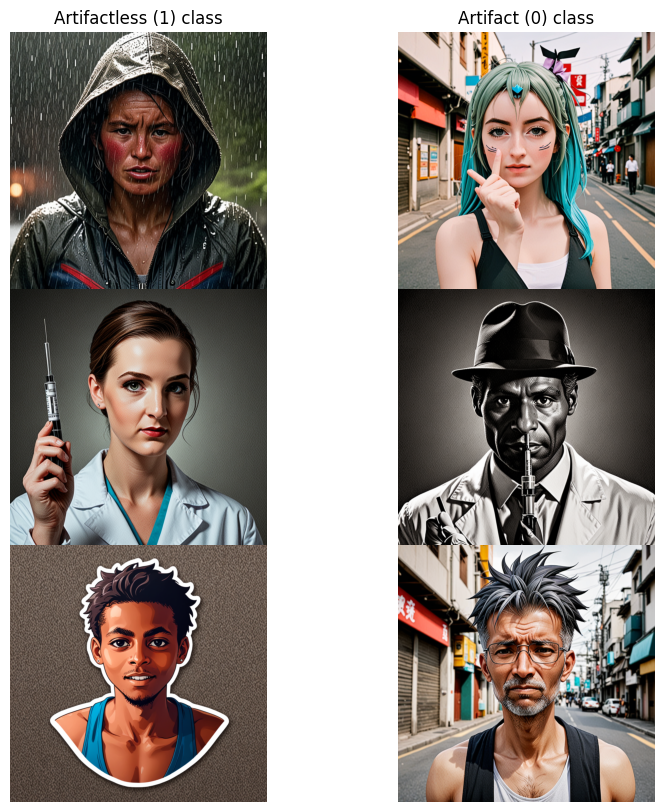

In [21]:
show_random_images(data_path / "train", n=3)

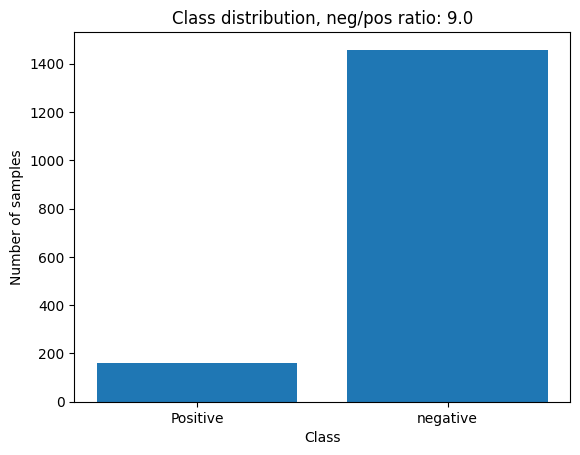

In [22]:
plot_class_distribution(data_path / "train")

Exploratory Data Analysis:
- [x] Calculate number of 0/1
- [x] Split to train/val
- [x] Remove duplicates - perceptual hashes

- [x] write func to remove duplications without repretions
- [x] write func to calculate duplications for different thresholds

#### Find duplicates

In [23]:
phasher = PHash()
encodings = phasher.encode_images(image_dir=data_path / "train")
threshold_results = []
for threshold in [3, 5, 7, 9]:
  duplicates = phasher.find_duplicates(encoding_map=encodings, max_distance_threshold = threshold)
  cnt, _ = count_duplicates(duplicates)
  threshold_results.append(f"Threshold: {threshold}, duplicates number: {cnt}")

2026-09-24 06:23:24,597: INFO Start: Calculating hashes...
INFO:imagededup.methods.hashing:Start: Calculating hashes...
100%|██████████| 1620/1620 [01:16<00:00, 21.20it/s]
2026-09-24 06:24:41,108: INFO End: Calculating hashes!
INFO:imagededup.methods.hashing:End: Calculating hashes!
/usr/local/lib/python3.13/dist-packages/imagededup/methods/hashing.py:317: RuntimeWarning: Parameter num_enc_workers has no effect since encodings are already provided
  warnings.warn('Parameter num_enc_workers has no effect since encodings are already provided', RuntimeWarning)
2026-09-24 06:24:41,112: INFO Start: Evaluating hamming distances for getting duplicates
INFO:imagededup.methods.hashing:Start: Evaluating hamming distances for getting duplicates
2026-09-24 06:24:41,115: INFO Start: Retrieving duplicates using Cython Brute force algorithm
INFO:imagededup.handlers.search.retrieval:Start: Retrieving duplicates using Cython Brute force algorithm
100%|██████████| 1620/1620 [00:01<00:00, 1295.85it/s]
20

In [24]:
for v in threshold_results:
  print(v)

Threshold: 3, duplicates number: 51
Threshold: 5, duplicates number: 196
Threshold: 7, duplicates number: 619
Threshold: 9, duplicates number: 1213


In [25]:
duplicates = phasher.find_duplicates(encoding_map=encodings, max_distance_threshold = 3)
_, duplicates = count_duplicates(duplicates)

2026-09-24 06:24:46,485: INFO Start: Evaluating hamming distances for getting duplicates
INFO:imagededup.methods.hashing:Start: Evaluating hamming distances for getting duplicates
2026-09-24 06:24:46,486: INFO Start: Retrieving duplicates using Cython Brute force algorithm
INFO:imagededup.handlers.search.retrieval:Start: Retrieving duplicates using Cython Brute force algorithm
100%|██████████| 1620/1620 [00:01<00:00, 1263.22it/s]
2026-09-24 06:24:47,835: INFO End: Retrieving duplicates using Cython Brute force algorithm
INFO:imagededup.handlers.search.retrieval:End: Retrieving duplicates using Cython Brute force algorithm
2026-09-24 06:24:47,837: INFO End: Evaluating hamming distances for getting duplicates
INFO:imagededup.methods.hashing:End: Evaluating hamming distances for getting duplicates


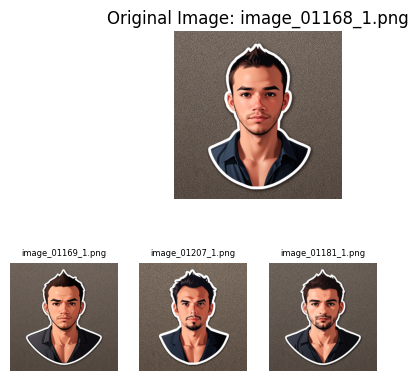

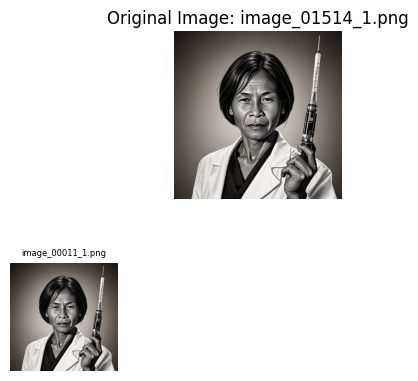

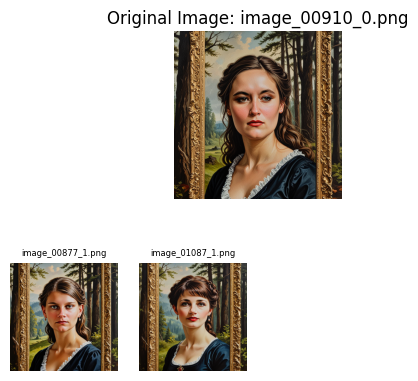

In [26]:
cnt = 0
for original_image, _ in duplicates.items():
  if len(_) != 0 and cnt < 3:
    plot_duplicates(image_dir=data_path / "train",
                    duplicate_map=duplicates,
                    filename=original_image)
    cnt += 1


In [27]:
remove_duplicates(duplicates, data_path / "train")

In [28]:
create_crop_face_data(data_path)

100%|██████████| 200/200 [02:35<00:00,  1.29it/s]


data/test_crop_face processed.


100%|██████████| 1595/1595 [20:24<00:00,  1.30it/s]


data/train_crop_face processed.


100%|██████████| 180/180 [02:18<00:00,  1.30it/s]

data/valid_crop_face processed.


Other things to do:

- [x] Create resnet model via pytorch
- [x] Create dataset class
- [x] Create training loop with results saving
- [x] Create pipeline for training with corresponding input parameters
- [x] Visualize training results

### Config creation

In [29]:
default_transform = torchvision.models.ResNet50_Weights.IMAGENET1K_V2.transforms()

In [30]:
custom_transform = transforms.Compose([
    transforms.Resize(
        224,
        interpolation=InterpolationMode.BILINEAR,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
      brightness=0.1,
      contrast=0.1,
      saturation=0.05,
      hue=0.02,
      ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [31]:
test_dataset = customImageDataset(data_path / "test", transform=default_transform)
valid_dataset = customImageDataset(data_path / "valid", transform=default_transform)

train_dataset_crop_faces = customImageDataset(data_path / "train_crop_face", transform=default_transform)
test_dataset_crop_faces = customImageDataset(data_path / "test_crop_face", transform=default_transform)
valid_dataset_crop_faces = customImageDataset(data_path / "valid_crop_face", transform=default_transform)


train_dataloader_crop_faces = DataLoader(train_dataset_crop_faces, batch_size=128, shuffle=True)
test_dataloader_crop_faces = DataLoader(test_dataset_crop_faces, batch_size=128, shuffle=True)
valid_dataloader_crop_faces = DataLoader(valid_dataset_crop_faces, batch_size=128, shuffle=True)

test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size = 128, shuffle=True)

# defaults
default_train_dataset = customImageDataset(data_path / "train", transform=default_transform)

# custom
custom_train_dataset = customImageDataset(data_path / "train", transform=custom_transform)

default_train_dataloader = DataLoader(default_train_dataset, batch_size=128, shuffle=True)
custom_train_dataloader = DataLoader(custom_train_dataset, batch_size=128, shuffle=True)
balanced_train_dataloader = DataLoader(default_train_dataset, batch_size=128, sampler=create_balanced_sampler(dataset=default_train_dataset))
oversample_train_dataloader = DataLoader(default_train_dataset, batch_size=128, sampler=create_oversampling_sampler(dataset=default_train_dataset))

Training ideas:
- [x] Baseline
- [x] Augmenation
- [x] Weightened BCE
- [x] Balanced Sampling
- [x] Oversampling
- [x] Focal loss

In [32]:
baseline_cfg = create_baseline_cfg(train_dataloader=default_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="baseline")
aug_cfg = create_baseline_cfg(train_dataloader=custom_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="data-augmentation")
cf_cfg = create_baseline_cfg(train_dataloader=train_dataloader_crop_faces,
                                   valid_dataloader=valid_dataloader_crop_faces,
                                   test_dataloader=test_dataloader_crop_faces,
                                   name = "crop-faces")
wc_cfg = create_baseline_cfg(train_dataloader=default_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="weighted-loss")

wc_cfg.criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1 / 9], device=wc_cfg.device))

fl_cfg = create_baseline_cfg(train_dataloader=default_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="focal-loss")

fl_cfg.criterion = lambda pred, target: sigmoid_focal_loss(
    pred,
    target.float(),
    alpha=0.25,
    gamma=2.0,
    reduction="mean",
)

balance_sampling_cfg = create_baseline_cfg(train_dataloader=balanced_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="balance-sampling")

oversample_cfg = create_baseline_cfg(train_dataloader=oversample_train_dataloader,
                                   valid_dataloader=valid_dataloader,
                                   test_dataloader=test_dataloader,
                                   name="oversampling")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


### Model training

In [33]:
cfg_list = [
    cf_cfg,
    baseline_cfg,
    aug_cfg,
    wc_cfg,
    fl_cfg,
    balance_sampling_cfg,
    oversample_cfg,
]
run_results = dict()
for cfg in cfg_list[5:]:
    run_results[cfg.name] = train_model(cfg)
    test_micro_f1, test_loss = valid_loop(model=cfg.model,
                                          criterion=cfg.criterion,
                                          data=cfg.test_dataloader,
                                          metric_func=cfg.metric_func,
                                          threshold=cfg.threshold,
                                          device=cfg.device)
    run_results[cfg.name].test_micro_f1 = test_micro_f1
    run_results[cfg.name].test_loss = test_loss

    save_training_data(run_results[cfg.name], cfg.save_dir + "/" + cfg.name)



 Epoch id   Train Loss     Valid Loss      Metric   
    1          0.299          0.990        0.890    
    2          0.094          0.182        0.975    
    3          0.043          0.297        0.969    
    4          0.064          0.233        0.967    
    5          0.014          0.283        0.967    
    6          0.008          0.190        0.979    
    7          0.002          0.181        0.976    
    8          0.001          0.163        0.979    
    9          0.001          0.145        0.985    
    10         0.001          0.165        0.982    
    11         0.000          0.161        0.982    
    12         0.000          0.168        0.982    
    13         0.000          0.166        0.982    
    14         0.001          0.169        0.982    
    15         0.001          0.170        0.982    
 Epoch id   Train Loss     Valid Loss      Metric   
    1          0.217          1.949        0.779    
    2          0.033          0.685        0.9

In [34]:
import shutil

shutil.make_archive("runs", "zip", "./runs")

'/content/working_dir/runs.zip'

- [x] create get labels func for a class
- [x] write balanced sampling

- [x] Test assessment function
- [x] dataloaders as a part of cfg
- [x] Save best/last models
- [x] Save models results to jsons to corresponding folder
- [x] add learning rate scheduler


Augmentation:
- [x] Train with 50% split chance
- [x] Focus for face


- [x] rewrite code for saving results
- [x] find models to zoom in faces
- [x] create config with zoomed in models
- [x] setup run for all models
- [x] run for all models
- [x] create github
- [ ] create readme with final results
- [ ] send it to the github
- [ ] restructure code
